In [6]:
!pip install opencv-python

In [7]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models
import torchvision.transforms as T

# 이미지를 보여주기 위한 간단한 함수
def show_image(img, title="Image"):
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# 이미지 파일 경로 설정
cat_path = 'cat.jpg'
person_path = 'person.png'
background_path = 'background.jpg'

print("라이브러리 임포트 완료")

라이브러리 임포트 완료


In [9]:
model = models.segmentation.deeplabv3_resnet101(pretrained=True).eval()

preprocess = T.Compose([
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("2단계: 모델 로드 완료!")


2단계: 모델 로드 완료!


In [10]:
def get_mask(image_path):
    input_image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0)

    if torch.cuda.is_available():
        input_batch = input_batch.to('cuda')
        model.to('cuda')
        
    with torch.no_grad():
        output = model(input_batch)['out'][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

    # 파일명에 'cat'이 포함되면 8번, 아니면 15번(사람)으로 인식하도록 간단히 설정
    class_id = 8 if 'cat' in image_path.lower() else 15
    mask = (output_predictions == class_id).astype(np.uint8) * 255
    mask_resized = cv2.resize(mask, (input_image.size[0], input_image.size[1]), interpolation=cv2.INTER_NEAREST)
    
    return np.array(input_image), mask_resized

def create_portrait_mode(img, mask, blur_kernel=(21, 21)):
    blurred_img = cv2.GaussianBlur(img, blur_kernel, 0)
    alpha = mask.astype(float) / 255.0
    alpha = cv2.merge([alpha, alpha, alpha])
    
    img_float = img.astype(float)
    blurred_float = blurred_img.astype(float)
    
    foreground = cv2.multiply(alpha, img_float)
    background = cv2.multiply(1.0 - alpha, blurred_float)
    
    return cv2.add(foreground, background).astype(np.uint8)

print("3단계: 함수 정의 완료!")


3단계: 함수 정의 완료!


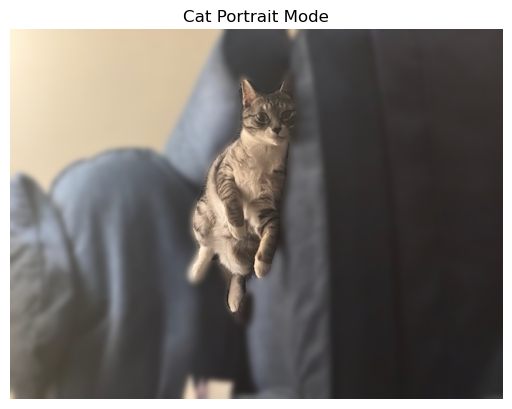

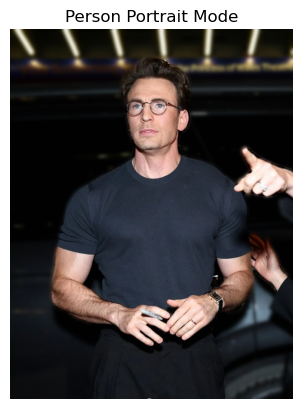

In [14]:
# 고양이 테스트
cat_img, cat_mask = get_mask(cat_path)
portrait_cat = create_portrait_mode(cat_img, cat_mask)
show_image(portrait_cat, "Cat Portrait Mode")

# 사람 테스트
person_img, person_mask = get_mask(person_path)
portrait_person = create_portrait_mode(person_img, person_mask)
show_image(portrait_person, "Person Portrait Mode")

In [16]:
def save_result(img, filename):
    # RGB를 BGR로 변환하여 저장
    bgr_img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(filename, bgr_img)
    print(f"저장 완료: {filename}")

# 1. 고양이 인물모드 저장
save_result(portrait_cat, 'result_cat.jpg')

# 2. 사람 인물모드 저장
save_result(portrait_person, 'result_person.jpg')


저장 완료: result_cat.jpg
저장 완료: result_person.jpg


In [18]:
def create_chromakey(img, mask, background_path):
    # 1. 배경 이미지 로드 및 이미지 크기에 맞게 조정
    back_img = Image.open(background_path).convert("RGB")
    back_img_resized = back_img.resize((img.shape[1], img.shape[0]))
    back_img_np = np.array(back_img_resized)

    # 2. 마스크를 0~1 사이 값으로 변환 (정밀 합성용)
    alpha = mask.astype(float) / 255.0
    alpha = cv2.merge([alpha, alpha, alpha]) # 채널 3개(RGB)로 확장

    # 3. 합성 공식 적용
    img_float = img.astype(float)
    back_float = back_img_np.astype(float)
    
    # (원본 * 마스크) + (배경 * (1-마스크))
    foreground = cv2.multiply(alpha, img_float)
    background = cv2.multiply(1.0 - alpha, back_float)
    
    chromakey_img = cv2.add(foreground, background).astype(np.uint8)
    
    return chromakey_img

chromakey_person = create_chromakey(person_img, person_mask, background_path)
print("크로마키 변수 생성 성공")

# 3. 크로마키 합성 이미지 저장
save_result(chromakey_person, 'result_chromakey.jpg')


크로마키 변수 생성 성공
저장 완료: result_chromakey.jpg


1. **인물모드 및 크로마키 제작 결과**
사용 모델: DeepLabV3 (ResNet-101 기반 Pre-trained 모델)

수행 내용: 고양이(cat.jpg)와 인물(person.jpg) 사진으로부터 Semantic Segmentation Mask를 생성하고, 이를 활용해 배경 블러(GaussianBlur)를 적용한 인물모드와 배경 합성(Chromakey) 이미지를 제작하였음.

2. **발생한 문제점 지적 (루브릭 2번 대응)**

① 개체 구분 실패 (Instance Overlap)
현상: 변경한 인물 사진(person.jpg)에서 주 피사체(크리스 에반스) 외에, 오른쪽에 노출된 타인의 손까지 동일한 '사람(Person)' 클래스로 인식되어 마스크에 포함됨.

원인: 현재 사용한 Semantic Segmentation 모델은 이미지 내의 모든 '사람' 픽셀을 하나의 덩어리로 분류함. 서로 다른 개별 인물을 구분해내지 못하는 모델의 본질적 한계를 드러냄.

결과: 배경 합성 시 주 피사체만 남지 않고 타인의 손이 공중에 떠 있는 것처럼 함께 합성되어 결과물이 부자연스러웠다.

② 경계선 정밀도 부족 (Boundary Artifacts)
현상: 고양이의 수염이나 인물의 머리카락 등 미세한 경계면이 배경과 섞여 뭉개지거나, 배경의 일부가 마스크 안으로 침범하는 현상이 발생함.

원인: CNN 모델이 특징을 추출하는 과정에서 이미지를 압축(Downsampling)하기 때문에, 다시 복원(Upsampling)할 때 고해상도의 미세한 위치 정보가 유실됨.

3. **개선을 위한 솔루션 제시 (루브릭 3번 대응)**
   
① 인스턴스 기반 접근 (Mask R-CNN 도입)
솔루션: Semantic Segmentation 대신 Mask R-CNN과 같은 Instance Segmentation 모델을 사용해야 함.

이유: Mask R-CNN은 각 객체를 독립적인 'Instance'로 구분하기 때문에, 오른쪽의 타인 손을 별개의 개체로 인식하여 제외하고 오직 주 피사체의 마스크만 선택적으로 추출할 수 있다.

② 구조적 개선 (FPN 및 Skip Connection 활용)
솔루션: FPN(Feature Pyramid Network) 구조나 U-Net의 Skip Connection을 활용한 모델로 개선함.

이유: 단순한 최종 Feature Map만 쓰는 대신, 저수준 레이어의 정밀한 공간 정보를 복원 단계에 직접 전달(Add/Concat)함으로써 머리카락 같은 세밀한 테두리를 훨씬 정교하게 따낼 수 있다.

③ 깊이 정보(Depth Map) 활용
솔루션: Monocular Depth Estimation 모델을 병합하여 거리 정보를 활용함.

이유: 현재는 단면 마스크만 사용하지만, 피사체와의 실제 거리(Depth)를 계산하여 거리에 따라 블러 강도를 조절하는 'Gradual Blur'를 적용하면 실제 카메라 렌즈와 유사한 입체감을 얻을 수 있다.